In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
datafile_path = "spotify_tracks_dataset.csv"

df = pd.read_csv(datafile_path)
df = df.dropna()

df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [4]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

X = df[features]
y = df['track_genre']

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Genre'] = y.values

explained_variance = pca.explained_variance_ratio_
print(f"Explained variance: {pca.explained_variance_ratio_}")

pca_df

Explained variance: [0.31928144 0.15850939]


,PC1,PC2,Genre
0,0.639565,1.081869,acoustic
1,-3.331079,1.009659,acoustic
2,-1.387508,-0.206647,acoustic
3,-3.379290,-0.651670,acoustic
4,-0.988600,0.255113,acoustic
...,...,...,...
113994,-3.926360,-1.983231,world-music
113995,-5.121165,-1.189219,world-music
113996,-1.130209,1.830281,world-music
113997,-0.470155,0.135088,world-music


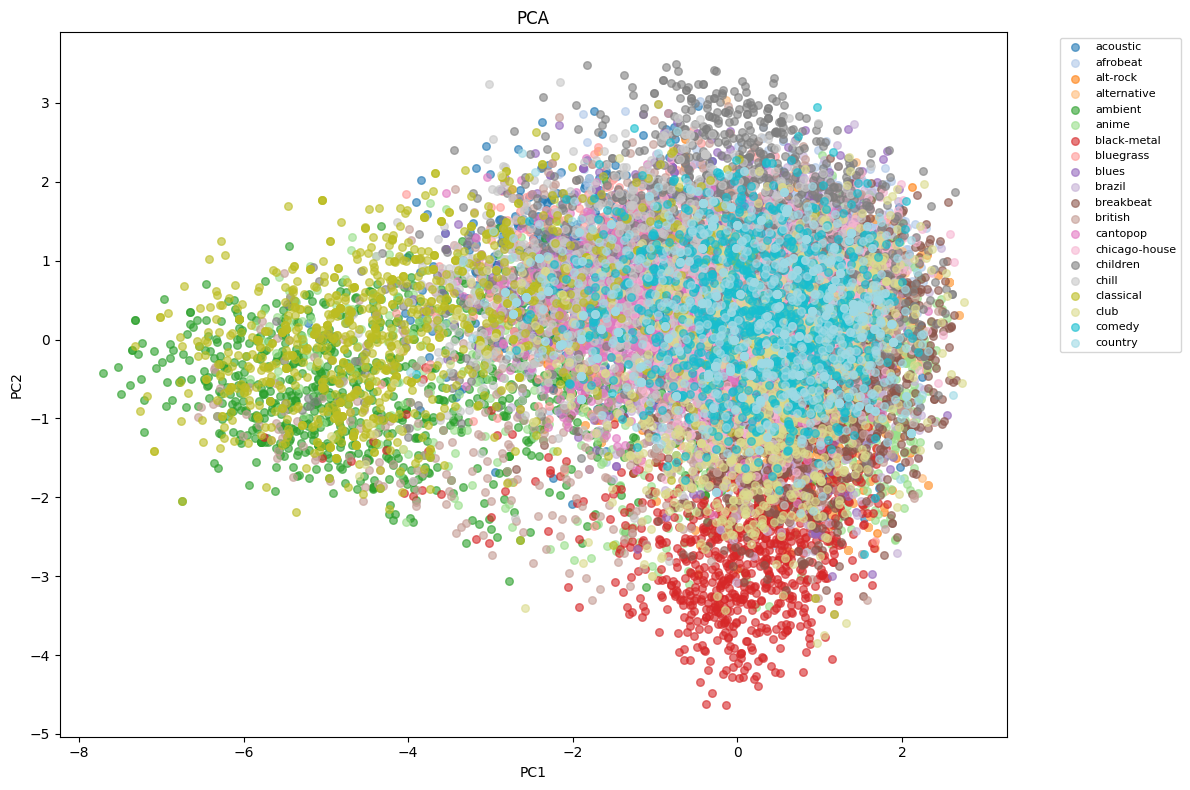

In [20]:
plt.figure(figsize=(12, 8))

genres = pca_df['Genre'].unique()[:20]
colors = plt.cm.tab20(np.linspace(0, 1, len(genres)))

for genre, color in zip(genres, colors):
    mask = pca_df['Genre'] == genre
    plt.scatter(pca_df.loc[mask, 'PC1'], 
                pca_df.loc[mask, 'PC2'], 
                c=[color], 
                label=genre, 
                alpha=0.6, 
                s=30)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title('PCA')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


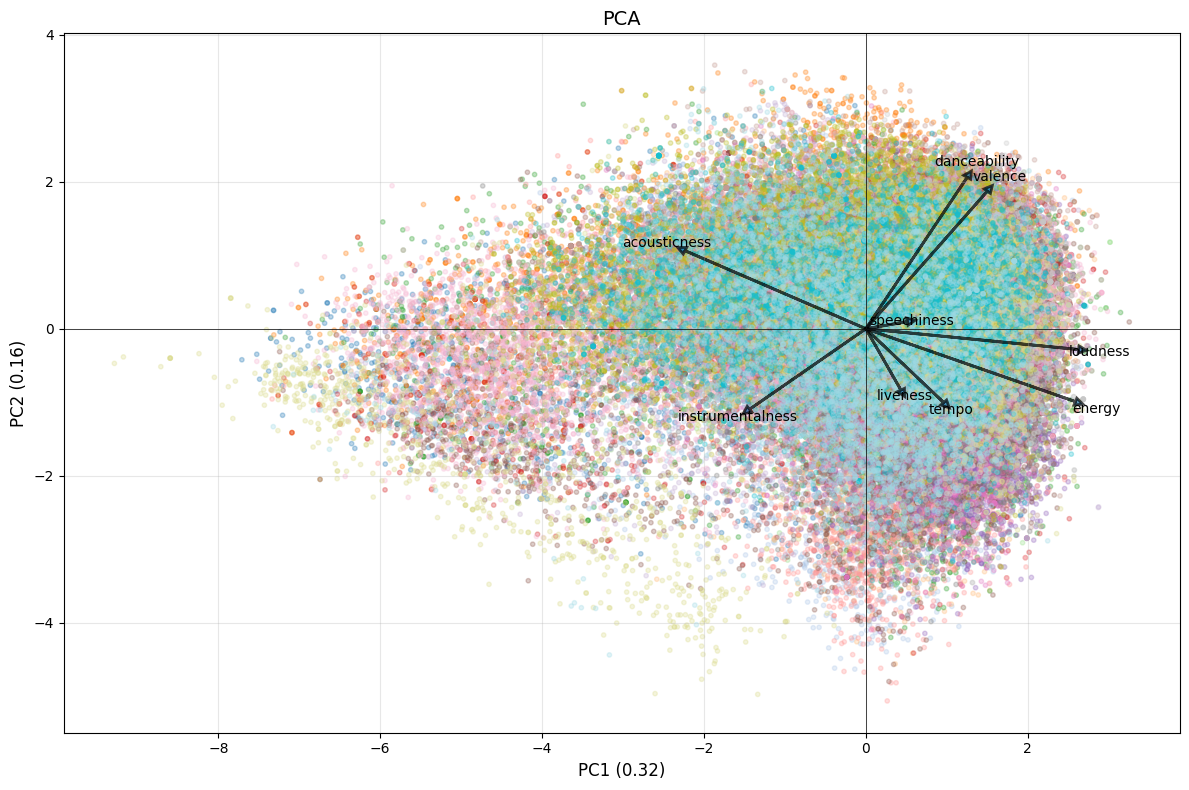

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], 
                    c=pd.Categorical(pca_df['Genre']).codes,
                    cmap='tab20', alpha=0.3, s=10)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(features):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
            head_width=0.1, head_length=0.1, linewidth=2, alpha=0.7)
    ax.text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, feature, 
            fontsize=10, ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2})', fontsize=12)
ax.set_title('PCA', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


In [50]:
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("\nPC1")
pc1_sorted = components_df['PC1'].abs().sort_values(ascending=False)
for i, (feature, value) in enumerate(pc1_sorted.items(), 1):
    actual_value = components_df.loc[feature, 'PC1']
    print(f"{i}. {feature} {abs(actual_value):.4f}")

print("\nPC2")
pc2_sorted = components_df['PC2'].abs().sort_values(ascending=False)
for i, (feature, value) in enumerate(pc2_sorted.items(), 1):
    actual_value = components_df.loc[feature, 'PC2']
    print(f"{i}. {feature} {abs(actual_value):.4f}")


PC1
1. loudness 0.5170
2. energy 0.5092
3. acousticness 0.4393
4. valence 0.2950
5. instrumentalness 0.2824
6. danceability 0.2461
7. tempo 0.1890
8. speechiness 0.1006
9. liveness 0.0851

PC2
1. danceability 0.5748
2. valence 0.5220
3. instrumentalness 0.3057
4. acousticness 0.2962
5. tempo 0.2800
6. energy 0.2767
7. liveness 0.2326
8. loudness 0.0789
9. speechiness 0.0270
